In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [92]:
df = pd.read_csv("https://raw.githubusercontent.com/patelparisha/ba820-b1-team10/dataset/Hollywood%20Age%20Gap/age_gaps.csv")
df.head()

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38


In [93]:
display(df.shape)
display(df.isna().sum())
display(df.dtypes)

(1155, 13)

,0
movie_name,0
release_year,0
director,0
age_difference,0
couple_number,0
actor_1_name,0
actor_2_name,0
character_1_gender,0
character_2_gender,0
actor_1_birthdate,0


,0
movie_name,object
release_year,int64
director,object
age_difference,int64
couple_number,int64
actor_1_name,object
actor_2_name,object
character_1_gender,object
character_2_gender,object
actor_1_birthdate,object


In [94]:
# Target variable: age gap (in years)
df["age_gap"] = pd.to_numeric(df["age_difference"], errors="coerce")

# Always create a baseline-adjusted time column (prevents formula errors)
BASE_YEAR = int(df["release_year"].min())
df["years_since_start"] = df["release_year"] - BASE_YEAR

# Decade bucket for time-based aggregation
df["decade"] = (df["release_year"] // 10) * 10

# Couple type label (used for couple-type comparisons)
df["pairing_type"] = (
    df["character_1_gender"].astype(str).str.strip().str.lower()
    + "–" +
    df["character_2_gender"].astype(str).str.strip().str.lower()
)

# Gender of older partner (actor_1 is older by dataset construction)
df["older_partner_gender"] = (
    df["character_1_gender"].astype(str).str.strip().str.title()
)

# Movie-level grouping key (movie + year)
movie_key = ["movie_name", "release_year"]

# Thresholds for interpretable summaries
LARGE_GAP = 20
PARITY_CUTOFF = 3

df["is_large_gap"] = df["age_gap"] >= LARGE_GAP
df["is_near_parity"] = df["age_gap"] <= PARITY_CUTOFF

df.head()


,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,actor_2_birthdate,actor_1_age,actor_2_age,age_gap,years_since_start,decade,pairing_type,older_partner_gender,is_large_gap,is_near_parity
0,Harold and Maude,1971,Hal Ashby,52,1,Ruth Gordon,Bud Cort,woman,man,1896-10-30,1948-03-29,75,23,52,36,1970,woman–man,Woman,True,False
1,Venus,2006,Roger Michell,50,1,Peter O'Toole,Jodie Whittaker,man,woman,1932-08-02,1982-06-03,74,24,50,71,2000,man–woman,Man,True,False
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,1982-10-01,69,20,49,67,2000,man–woman,Man,True,False
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,1975-11-08,68,23,45,63,1990,man–woman,Man,True,False
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,1972-09-09,81,38,43,75,2010,man–man,Man,True,False


## Age Gap Distribution

In [95]:
# Basic summary
display(df["age_gap"].describe())

# Check for negative or extreme values (sanity)
df.loc[(df["age_gap"] < 0) | (df["age_gap"] > 80),
       ["movie_name","release_year","age_difference","age_gap",
        "character_1_gender","character_2_gender","actor_1_age","actor_2_age"]].head(20)


,age_gap
count,1155.000000
mean,10.424242
std,8.511086
min,0.000000
25%,4.000000
50%,8.000000
75%,15.000000
max,52.000000


,movie_name,release_year,age_difference,age_gap,character_1_gender,character_2_gender,actor_1_age,actor_2_age


The average age gap is about 10.4 years, and the median is 8, which suggests most movie couples have a moderate gap rather than something huge. But since the upper end goes up to 52 years, a smaller set of films still feature really large age differences.

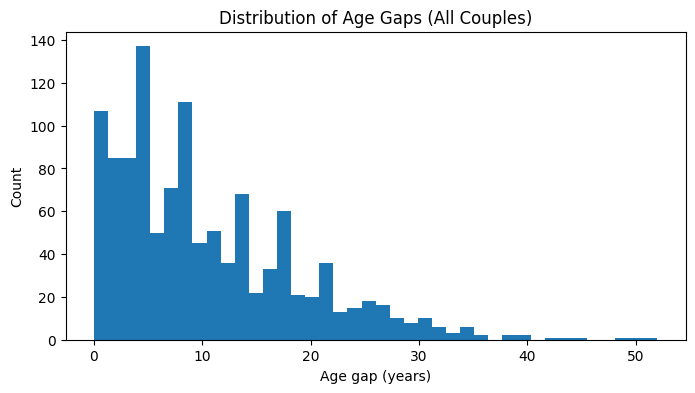

In [96]:
plt.figure(figsize=(8,4))
plt.hist(df["age_gap"].dropna(), bins=40)
plt.title("Distribution of Age Gaps (All Couples)")
plt.xlabel("Age gap (years)")
plt.ylabel("Count")
plt.show()


The age-gap distribution is right-skewed, most couples have small age differences, but there’s a long tail of couples with very large age gaps.

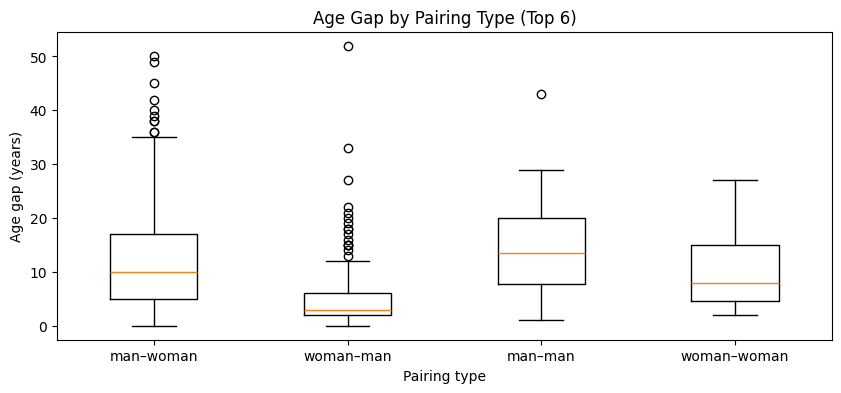

In [97]:
# Optional: keep only common pairing types to avoid messy plots
top_pairings = df["pairing_type"].value_counts().head(6).index
tmp = df[df["pairing_type"].isin(top_pairings)].copy()

plt.figure(figsize=(10,4))
plt.boxplot([tmp.loc[tmp["pairing_type"]==pt, "age_gap"].dropna() for pt in top_pairings],
            tick_labels=top_pairings)
plt.title("Age Gap by Pairing Type (Top 6)")
plt.xlabel("Pairing type")
plt.ylabel("Age gap (years)")
plt.show()


From the boxplot, man–woman pairings show a wider spread in age gaps and more extreme high-end outliers, suggesting that large age differences are more common in these pairings. In contrast, woman–man pairings have a tighter distribution (smaller IQR) with fewer and less extreme outliers, indicating that when the woman is older, age gaps tend to be smaller and less variable.

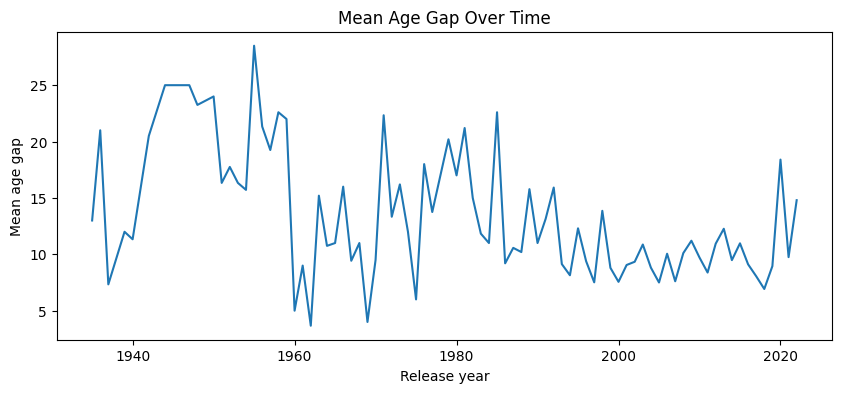

In [98]:
# Average by year (smooth later if needed)
yearly = df.groupby("release_year")["age_gap"].mean()

plt.figure(figsize=(10,4))
plt.plot(yearly.index, yearly.values)
plt.title("Mean Age Gap Over Time")
plt.xlabel("Release year")
plt.ylabel("Mean age gap")
plt.show()


The year-by-year mean age gap does not show a clear trend; instead it fluctuates with noticeable spikes. This volatility may be driven by uneven numbers of films/couples per year and the influence of outliers, so the raw annual series may obscure any underlying time pattern.

## Sub-Table: Movies with multiple pairings

In [99]:
movie_key = ["movie_name", "release_year"]

# Count couples per movie
couples_per_movie = df.groupby(movie_key).size().reset_index(name="n_couples")

# Attach count back to each row
df_with_counts = df.merge(couples_per_movie, on=movie_key, how="left")

# Subset: movies with 2+ couples
multi_pairs = df_with_counts[df_with_counts["n_couples"] >= 2].copy()

display(multi_pairs.shape)
multi_pairs.head()


(541, 21)

,movie_name,release_year,director,age_difference,couple_number,actor_1_name,actor_2_name,character_1_gender,character_2_gender,actor_1_birthdate,...,actor_1_age,actor_2_age,age_gap,years_since_start,decade,pairing_type,older_partner_gender,is_large_gap,is_near_parity,n_couples
2,The Quiet American,2002,Phillip Noyce,49,1,Michael Caine,Do Thi Hai Yen,man,woman,1933-03-14,...,69,20,49,67,2000,man–woman,Man,True,False,2
3,The Big Lebowski,1998,Joel Coen,45,1,David Huddleston,Tara Reid,man,woman,1930-09-17,...,68,23,45,63,1990,man–woman,Man,True,False,2
4,Beginners,2010,Mike Mills,43,1,Christopher Plummer,Goran Visnjic,man,man,1929-12-13,...,81,38,43,75,2010,man–man,Man,True,False,2
6,Whatever Works,2009,Woody Allen,40,1,Larry David,Evan Rachel Wood,man,woman,1947-07-02,...,62,22,40,74,2000,man–woman,Man,True,False,3
8,Husbands and Wives,1992,Woody Allen,38,1,Woody Allen,Juliette Lewis,man,woman,1935-12-01,...,57,19,38,57,1990,man–woman,Man,True,False,3


## Multi-Pair Movies summary table

In [100]:
LARGE_GAP = 20

movie_summary = (multi_pairs
    .groupby(movie_key)
    .agg(
        n_couples=("age_gap", "size"),
        mean_gap=("age_gap", "mean"),
        median_gap=("age_gap", "median"),
        std_gap=("age_gap", "std"),
        min_gap=("age_gap", "min"),
        max_gap=("age_gap", "max"),
        # Counts how many couple have a large age gap
        count_large=("age_gap", lambda x: (x >= LARGE_GAP).sum()),
        # proportion of couples in the movie that have a larger age gap
        share_large=("age_gap", lambda x: (x >= LARGE_GAP).mean()),
    )
    .reset_index()
)

# "Headline" dominance: biggest gap compared to the typical gap in that film
movie_summary["headline_score"] = movie_summary["max_gap"] - movie_summary["median_gap"]

movie_summary.head()


,movie_name,release_year,n_couples,mean_gap,median_gap,std_gap,min_gap,max_gap,count_large,share_large,headline_score
0,10 Things I Hate About You,1999,2,1.0,1.0,1.414214,0,2,0,0.0,1.0
1,27 Dresses,2008,2,7.5,7.5,3.535534,5,10,0,0.0,2.5
2,A Happening of Monumental Proportions,2017,2,4.0,4.0,5.656854,0,8,0,0.0,4.0
3,A Perfect Murder,1998,2,21.0,21.0,9.899495,14,28,1,0.5,7.0
4,A Simple Favor,2018,2,1.0,1.0,1.414214,0,2,0,0.0,1.0


## M2: Within-Film Age-Gap Concentration vs Recurrence in Multi-Couple Movies

In this milestone, The main goal is to test whether age gaps in these movies tend to concentrate in one standout couple (“headline” pattern) or repeat across multiple couples within the same film (“recurrence” pattern).

This matters because if age gaps are mostly concentrated in one pairing, it supports the idea that age gaps are being used as a deliberate narrative device. If large gaps consistently recur across couples in the same movie, it suggests a broader within-film casting norm.

####1) Headline dominance in multi-couple films


TABLE 3 — Multi-couple movies: within-film dispersion + headline dominance by #couples


,n_couples,n_movies,avg_range,median_range,avg_headline_share,median_headline_share
0,2,156,8.63,6.0,0.731,0.714
1,3,51,12.45,11.0,0.538,0.519
2,4,12,10.83,11.5,0.455,0.426
3,5,3,14.33,9.0,0.413,0.474
4,6,1,15.00,15.0,0.421,0.421
5,7,1,18.00,18.0,0.260,0.260


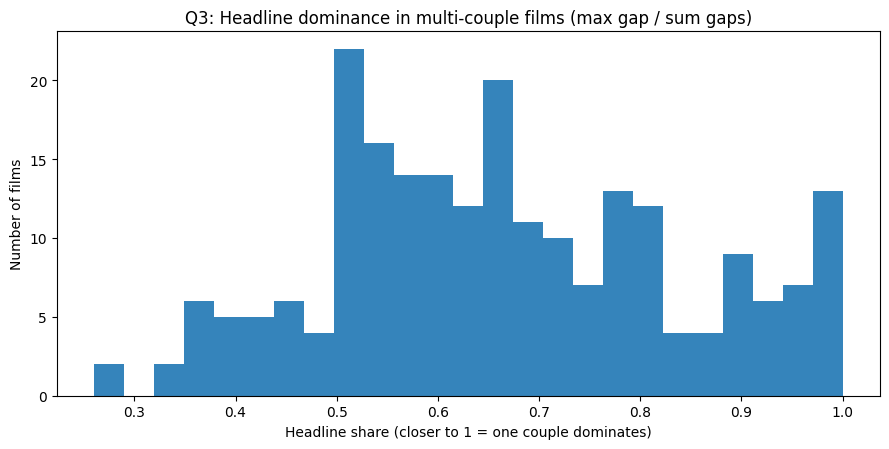

In [101]:
movie_stats = (
    df.groupby(movie_key)
      .agg(
          n_couples=("age_gap", "size"),
          max_gap=("age_gap", "max"),
          min_gap=("age_gap", "min"),
          mean_gap=("age_gap", "mean"),
          std_gap=("age_gap", "std"),
          sum_gap=("age_gap", "sum"),
      )
      .reset_index()
)

# Within-movie dispersion + dominance measures
movie_stats["range_gap"] = movie_stats["max_gap"] - movie_stats["min_gap"]
movie_stats["headline_share"] = movie_stats["max_gap"] / movie_stats["sum_gap"]

multi = movie_stats[movie_stats["n_couples"] > 1].copy()

# ---- TABLE 3: How dispersion + dominance change with number of couples
table3 = (
    multi.groupby("n_couples")
         .agg(
             n_movies=("movie_name", "size"),
             avg_range=("range_gap", "mean"),
             median_range=("range_gap", "median"),
             avg_headline_share=("headline_share", "mean"),
             median_headline_share=("headline_share", "median"),
         )
         .reset_index()
         .sort_values("n_couples")
)

table3["avg_range"] = table3["avg_range"].round(2)
table3["median_range"] = table3["median_range"].round(2)
table3["avg_headline_share"] = table3["avg_headline_share"].round(3)
table3["median_headline_share"] = table3["median_headline_share"].round(3)

print("\nTABLE 3 — Multi-couple movies: within-film dispersion + headline dominance by #couples")
display(table3)

# ---- CHART 3: Distribution of headline dominance
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.hist(multi["headline_share"].dropna(), bins=25, alpha=0.90)

ax.set_title("Q3: Headline dominance in multi-couple films (max gap / sum gaps)")
ax.set_xlabel("Headline share (closer to 1 = one couple dominates)")
ax.set_ylabel("Number of films")

plt.tight_layout()
plt.show()

The histogram shows headline share is usually pretty high, so in a lot of multi-couple movies one couple dominates the age-gap story. Table 3 shows this most clearly for 2-couple movies (avg headline share ≈ 0.73), but as the number of couples increases, headline share drops (closer to ~0.5 or lower), meaning the age gaps get spread out more evenly across couples instead of being concentrated in one pairing.

####2) Multi-couple coverage

Total unique movies: 838
Multi-couple movies (2+ couples): 224 (26.7%)

Couples per multi-couple movie:
n_couples
2    156
3     51
4     12
5      3
6      1
7      1
Name: count, dtype: int64


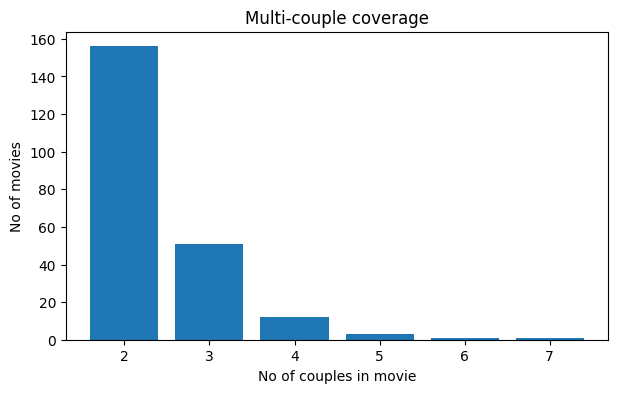

In [102]:
total_movies = df.drop_duplicates(subset=movie_key).shape[0]
multi_movies = movie_summary.shape[0]
pct_multi = 100 * multi_movies / total_movies

print(f"Total unique movies: {total_movies}")
print(f"Multi-couple movies (2+ couples): {multi_movies} ({pct_multi:.1f}%)")

dist = movie_summary["n_couples"].value_counts().sort_index()
print("\nCouples per multi-couple movie:")
print(dist)

plt.figure(figsize=(7,4))
plt.bar(dist.index.astype(str), dist.values)
plt.title("Multi-couple coverage")
plt.xlabel("No of couples in movie")
plt.ylabel("No of movies")
plt.show()


Out of 838 total movies, 224 of them (26.7%) have 2 or more couples, so there’s a decent chunk of the dataset where within-film comparisons actually make sense. But within those multi-couple movies. Most multi-couple films in this dataset contain exactly two couples, and the number of movies drops sharply once you move to 3+ couples. In other words, the multi-couple sample is heavily dominated by 2-couple movies, so any “within-movie recurrence” patterns you observe will be driven mostly by films with just two pairings.

Because of that distribution, the business question should be tweaked slightly. Instead of focusing broadly on “do age gaps recur across couples within the same film,” the dataset mostly supports a more binary framing for the typical multi-couple movie: does a large age gap appear in only one couple (a headline pairing), or does it show up in both couples (recurrence within the film)? You can still analyze 3+ couple films separately, but they represent a much smaller share of the data.

####3) Couple Ordering Validity

Before treating “Couple #1” as the main or headline relationship, I needed to check what the couple_number column actually means in this dataset.

In [103]:
# Overall check
overall_older_rate = (df["actor_1_age"] >= df["actor_2_age"]).mean()
overall_strict_rate = (df["actor_1_age"] > df["actor_2_age"]).mean()

print(f"Overall: actor_1_age >= actor_2_age in {overall_older_rate:.2%} of rows")
print(f"Overall: actor_1_age >  actor_2_age in {overall_strict_rate:.2%} of rows")

# Couple #1 only
c1 = df[df["couple_number"] == 1]
c1_older_rate = (c1["actor_1_age"] >= c1["actor_2_age"]).mean()
c1_strict_rate = (c1["actor_1_age"] >  c1["actor_2_age"]).mean()

print(f"Couple #1: actor_1_age >= actor_2_age in {c1_older_rate:.2%} of rows")
print(f"Couple #1: actor_1_age >  actor_2_age in {c1_strict_rate:.2%} of rows")

Overall: actor_1_age >= actor_2_age in 100.00% of rows
Overall: actor_1_age >  actor_2_age in 97.40% of rows
Couple #1: actor_1_age >= actor_2_age in 100.00% of rows
Couple #1: actor_1_age >  actor_2_age in 98.55% of rows


The results show that actor_1 is always the older (or same-age) partner, so each couple is recorded in a consistent order rather than randomly. More importantly, in multi-couple movies couple_number appears to be ordered by age-gap size (with couple #1 typically representing the largest gap), meaning it shouldn’t be interpreted as the “main couple” in the story.

####4) Standout vs Recurrence Within the Same Movie

Now that I know multi-couple movies are mostly 2-couple films and that couple numbers seem to be ordered by age gap size, the next step is to directly test the core idea: is the biggest age gap usually a one-off standout, or do large gaps show up in additional couples in the same movie?

In [104]:
# per movie: largest gap, 2nd largest gap, dominance
top2 = (multi_pairs.groupby(movie_key)["age_gap"]
        .apply(lambda s: s.sort_values(ascending=False).head(2).tolist())
        .reset_index(name="top2_gaps"))

top2[["max_gap","second_gap"]] = pd.DataFrame(top2["top2_gaps"].tolist(), index=top2.index)
top2["top_gap_dominance"] = top2["max_gap"] - top2["second_gap"]

# keep ONLY the columns you actually need to add (avoid max_gap collisions)
top2 = top2[movie_key + ["second_gap", "top_gap_dominance"]]

# merge into your movie_summary
eda3 = movie_summary.merge(top2, on=movie_key, how="left")
eda3["second_is_large"] = eda3["second_gap"] >= LARGE_GAP

print("Percent of multi-couple movies where the 2nd largest gap is also large (>=20):",
      f"{eda3['second_is_large'].mean():.2%}")


Percent of multi-couple movies where the 2nd largest gap is also large (>=20): 4.46%


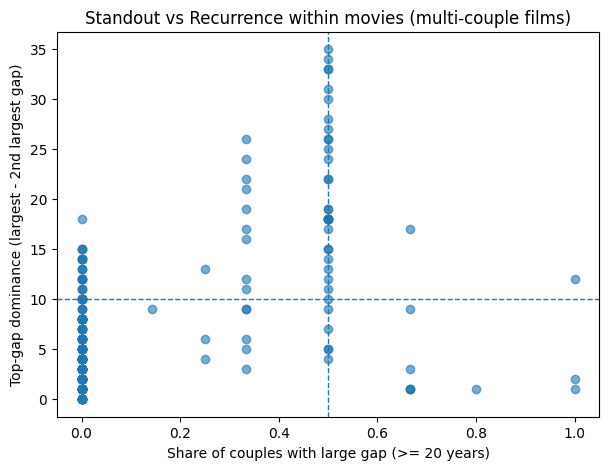

In [105]:
plt.figure(figsize=(7,5))
plt.scatter(eda3["share_large"], eda3["top_gap_dominance"], alpha=0.6)
plt.xlabel("Share of couples with large gap (>= 20 years)")
plt.ylabel("Top-gap dominance (largest - 2nd largest gap)")
plt.title("Standout vs Recurrence within movies (multi-couple films)")

plt.axvline(0.5, linestyle="--", linewidth=1)
plt.axhline(10, linestyle="--", linewidth=1)
plt.show()


This plot compares recurrence (x-axis: share of couples with a large age gap ≥ 20) with headline dominance (y-axis: how much bigger the largest gap is than the second-largest). Most movies cluster at share_large = 0.5, which mainly reflects that most multi-couple films have exactly two couples, so a lot of the time, only one of the two couples is a “large-gap” pairing. Many of those same movies also have fairly high dominance (often above ~10), suggesting the large age gap is usually concentrated in one standout couple rather than repeating evenly across pairings.

####5) Recurrence Rate by Movie Structure (2 Couples vs 3+ Couples)

Since the earlier EDA showed that most multi-couple movies only have two couples, “recurrence” can’t be interpreted the same way for every film. With only two couples, recurrence basically means both couples have large age gaps, while movies with 3+ couples allow a more realistic test of whether large gaps repeat across multiple pairings. So I split movies into 2-couple vs 3+ couple buckets and computed recurrence rates separately to make the comparison fair and interpretable.

In [106]:
# make a copy so eda3 stays clean
tmp = eda3.copy()

tmp["bucket"] = np.where(tmp["n_couples"] == 2, "2 couples", "3+ couples")

# Recurrence definitions tailored to structure
tmp["recur_2couples"] = tmp["second_gap"] >= LARGE_GAP   # for 2-couple movies
tmp["recur_3plus"]    = tmp["count_large"] >= 2         # for 3+ couple movies

rate_table = pd.DataFrame({
    "bucket": ["2 couples", "3+ couples"],
    "n_movies": [
        (tmp["bucket"] == "2 couples").sum(),
        (tmp["bucket"] == "3+ couples").sum()
    ],
    "recurrence_rate": [
        tmp.loc[tmp["bucket"] == "2 couples", "recur_2couples"].mean(),
        tmp.loc[tmp["bucket"] == "3+ couples", "recur_3plus"].mean()
    ]
})

rate_table["recurrence_rate"] = (rate_table["recurrence_rate"] * 100).round(1)
display(rate_table)


,bucket,n_movies,recurrence_rate
0,2 couples,156,0.6
1,3+ couples,68,13.2


Recurrence is extremely rare in 2-couple movies: only 0.6% of those films have the second-largest gap also ≥ 20 years (basically ~1 movie out of 156). In contrast, recurrence is noticeably more common in 3+ couple movies, where 13.2% of films have at least two large-gap couples. Overall, this suggests that large age gaps are usually isolated to one standout pairing, but once a film includes more couples, there’s a higher chance that large age gaps reflect a broader within-film pattern rather than a single “headline” couple.

## Unsupervised Machine Learning Techniques

#### 1) K - Means Clustering

I’m setting up the movie-level data for K-means using features that match my question (headline dominance + recurrence + typical gap + how many couples). I scaled everything since K-means is distance-based and I don’t want one column to dominate.

In [107]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

cluster_data = eda3.copy()

# keep features interpretable + directly tied to your question
features = ["top_gap_dominance", "second_gap", "median_gap", "count_large", "n_couples"]

X = cluster_data[features].dropna().copy()
cluster_data_used = cluster_data.loc[X.index].copy()

# scale for KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Rows used for clustering:", X.shape[0])
print("Features:", features)

Rows used for clustering: 224
Features: ['top_gap_dominance', 'second_gap', 'median_gap', 'count_large', 'n_couples']


I have 224 multi-couple movies going into clustering. The features list also makes sense for my story since it directly captures “standout vs recurring” age-gap patterns.

I’m testing a range of k = 2 to 8 and saving two metrics: inertia (for the elbow) and silhouette (for how clean the clusters are).

In [108]:
# Compute elbow (inertia) + silhouette across k
Ks = range(2, 9)
inertias = []
sil_scores = []

for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

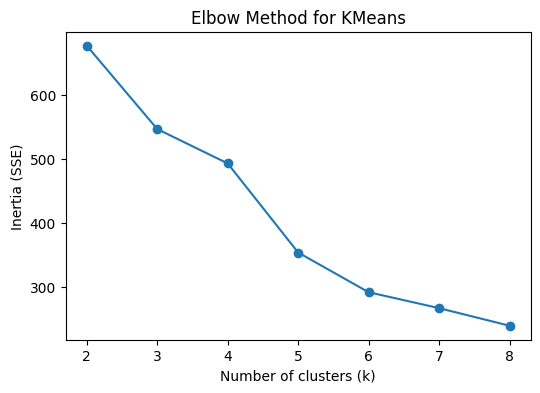

In [109]:
# Plot elbow curve
plt.figure(figsize=(6,4))
plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (SSE)")
plt.title("Elbow Method for KMeans")
plt.show()


In [110]:
# Results table + best k (by silhouette)
results = pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": sil_scores})
display(results)

# Save the exact rows used in clustering
cluster_data_used = cluster_data.loc[X.index].copy()

,k,inertia,silhouette
0,2,676.833175,0.471301
1,3,546.650680,0.379884
2,4,492.983435,0.278306
3,5,353.828095,0.323907
4,6,291.854230,0.331321
5,7,266.979992,0.328847
6,8,239.503850,0.320168


In [111]:
# Fit final KMeans model (choose k after reviewing results)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
labels = kmeans.fit_predict(X_scaled)

# attach labels to the exact rows used in clustering
cluster_data_vis = cluster_data_used.copy()
cluster_data_vis["cluster"] = labels

print("Cluster sizes:")
print(cluster_data_vis["cluster"].value_counts().sort_index())


Cluster sizes:
cluster
0    124
1     58
2     42
Name: count, dtype: int64


Based on the silhouette results and the elbow plot,k=2 has the best silhouette but is probably too coarse; k=5 is near the elbow and gives a more detailed segmentation; k = 3 provides a reasonable clustering solution: it maintains moderate separation between clusters (silhouette ≈ 0.38) while producing groups that are still large and interpretable. Higher k values lower the silhouette score and start to split the data into less distinct, noisier clusters, so k=3 is a good balance.

I’m using PCA after clustering just as a visualization tool. Since my movie-level feature space is 5-dimensional, PCA lets me project it down to 2 dimensions so I can see whether the clusters look separated or heavily overlapping. It doesn’t change the clustering itself, it just gives a simple way to sanity-check and explain the cluster structure.

In [112]:
# Cluster profiles (use median = more stable than mean)
cluster_profile = (
    cluster_data_vis.groupby("cluster")[features]
    .median()
    .round(2)
)
print("Cluster profiles (median):")
display(cluster_profile)


Cluster profiles (median):


,top_gap_dominance,second_gap,median_gap,count_large,n_couples
cluster,,,,,
0,4.5,3.0,6.75,0.0,2.0
1,17.0,13.5,18.00,1.0,2.0
2,4.0,8.5,7.00,0.0,3.0


In [113]:
# Give clusters human-readable names (edit based on cluster_profile)
cluster_names = {
    0: "Headline-dominant",
    1: "Recurrence-leaning",
    2: "Low-gap / typical"
}

cluster_data_vis["cluster_name"] = cluster_data_vis["cluster"].map(cluster_names)

print("Cluster sizes:")
print(cluster_data_vis["cluster_name"].value_counts())


Cluster sizes:
cluster_name
Headline-dominant     124
Recurrence-leaning     58
Low-gap / typical      42
Name: count, dtype: int64


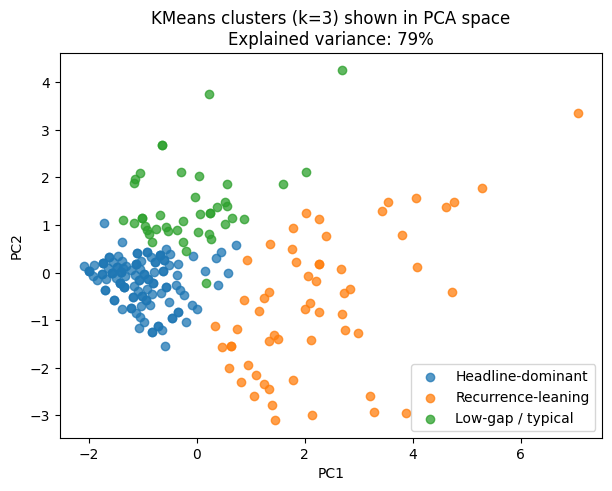

In [114]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2D for visualization (after clustering)
pca2 = PCA(n_components=2, random_state=42)
Z2 = pca2.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
for c, name in cluster_names.items():
    idx = (cluster_data_vis["cluster"] == c).values
    plt.scatter(Z2[idx, 0], Z2[idx, 1], alpha=0.75, label=name)

plt.title(f"KMeans clusters (k={k}) shown in PCA space\nExplained variance: {pca2.explained_variance_ratio_.sum():.0%}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.show()


In this PCA plot, the k=3 clusters look pretty separated, which makes me feel better about the clustering. The Headline dominant group (blue) is tight and packed together, so those movies seem to share a really similar “one standout couple” pattern. The Low gap / typical cluster (green) sits nearby but is a bit more spread out, which suggests those films have smaller gaps overall but still some variation. The Recurrence leaning cluster (orange) is the most scattered and stretched out, meaning it’s a more mixed group with some movies that are clear recurrence cases and others that are kind of borderline, so it’s not as “clean” as the headline dominant cluster.

####2) PCA for dimesionality reduction (Experiment)

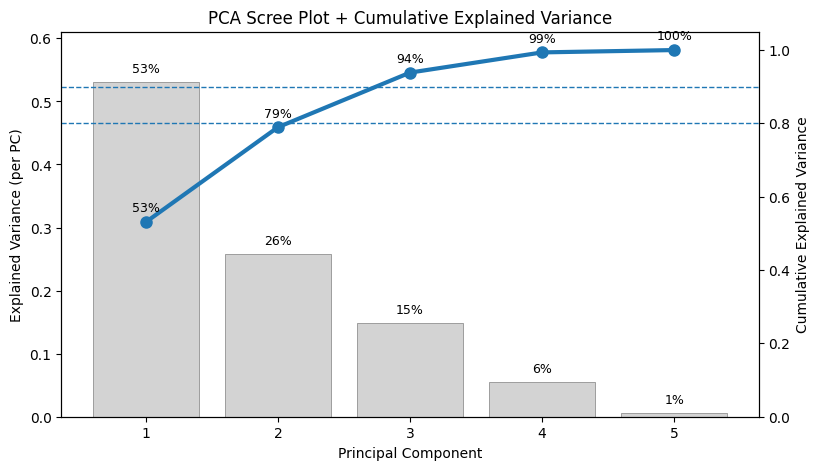

In [115]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Fit PCA
pca = PCA().fit(X_scaled)
expl_var = pca.explained_variance_ratio_
cum_var = np.cumsum(expl_var)
pcs = np.arange(1, len(expl_var) + 1)

fig, ax1 = plt.subplots(figsize=(9,5))

# Bars: explained variance per PC (light grey)
ax1.bar(pcs, expl_var, color="lightgrey", edgecolor="grey", linewidth=0.5, zorder=1)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Explained Variance (per PC)")
ax1.set_xticks(pcs)
ax1.set_ylim(0, max(expl_var) * 1.15)

# bar labels
for x, v in zip(pcs, expl_var):
    ax1.text(x, v + 0.01, f"{v:.0%}", ha="center", va="bottom", fontsize=9, zorder=3)

# Line: cumulative variance (drawn in front, thicker, bigger markers)
ax2 = ax1.twinx()
ax2.plot(pcs, cum_var, marker="o", linewidth=3, markersize=8, zorder=5)
ax2.set_ylabel("Cumulative Explained Variance")
ax2.set_ylim(0, 1.05)

# Cumulative labels
for x, cv in zip(pcs, cum_var):
    ax2.text(x, cv + 0.02, f"{cv:.0%}", ha="center", va="bottom", fontsize=9, zorder=6)

# Threshold lines
ax2.axhline(0.80, linestyle="--", linewidth=1)
ax2.axhline(0.90, linestyle="--", linewidth=1)

plt.title("PCA Scree Plot + Cumulative Explained Variance")
plt.show()


From the scree plot, the first three principal components explain about 94% of the total variance (PC1 ≈ 53%, PC2 brings it to ≈ 79%, and PC3 to ≈ 94%). After PC3, the additional gain is small (PC4 adds ~6% and PC5 ~1%). So using 3 PCs is a good tradeoff: it keeps most of the information while reducing dimensionality and potential noise.

I tried clustering in the original feature space and also in PCA space (2 PCs and 3 PCs) just to see if dimensionality reduction makes the clusters cleaner. Since 3 PCs keep most of the information from the scree plot, I expect the silhouette score to improve a bit.

In [116]:
# Experiment setup: create PCA versions of the same data
from sklearn.decomposition import PCA

pca_2 = PCA(n_components=2, random_state=42)
X_pca2 = pca_2.fit_transform(X_scaled)

pca_3 = PCA(n_components=3, random_state=42)
X_pca3 = pca_3.fit_transform(X_scaled)

pca_4 = PCA(n_components=4, random_state=42)
X_pca4 = pca_4.fit_transform(X_scaled)

pca_5 = PCA(n_components=5, random_state=42)
X_pca5 = pca_5.fit_transform(X_scaled)

print("Variance captured by 2 PCs:", round(pca_2.explained_variance_ratio_.sum(), 3))
print("Variance captured by 3 PCs:", round(pca_3.explained_variance_ratio_.sum(), 3))
print("Variance captured by 4 PCs:", round(pca_4.explained_variance_ratio_.sum(), 3))
print("Variance captured by 5 PCs:", round(pca_5.explained_variance_ratio_.sum(), 3))


Variance captured by 2 PCs: 0.79
Variance captured by 3 PCs: 0.939
Variance captured by 4 PCs: 0.994
Variance captured by 5 PCs: 1.0


In [117]:
# Run KMeans on original features vs PCA-compressed features and compare silhouette/inertia

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pandas as pd

def eval_kmeans(X_in, k, seed=42):
    km = KMeans(n_clusters=k, random_state=seed, n_init="auto")
    labels = km.fit_predict(X_in)
    return km.inertia_, silhouette_score(X_in, labels)

k_test = k  # uses your chosen k (ex: 3)

in0, sil0 = eval_kmeans(X_scaled, k_test)
in2, sil2 = eval_kmeans(X_pca2,  k_test)
in3, sil3 = eval_kmeans(X_pca3,  k_test)
in4, sil4 = eval_kmeans(X_pca4,  k_test)
in5, sil5 = eval_kmeans(X_pca5,  k_test)


compare = pd.DataFrame({
    "space": ["Original 5 features", "PCA 2 PCs", "PCA 3 PCs", "PCA 4 PCs", "PCA 5 PCs"],
    "inertia": [in0, in2, in3, in4, in5],
    "silhouette": [sil0, sil2, sil3, sil4, sil5]
})

display(compare)


,space,inertia,silhouette
0,Original 5 features,546.650680,0.379884
1,PCA 2 PCs,346.554801,0.429839
2,PCA 3 PCs,464.939110,0.480166
3,PCA 4 PCs,539.517951,0.381096
4,PCA 5 PCs,546.650680,0.379884


I tested KMeans in the original feature space and in PCA space from 2 to 5 components. The clusters were cleanest with PCA 3 (silhouette ≈ 0.48), and PCA 2 also improved separation compared to the original. But when I used PCA 4 or PCA 5, the silhouette dropped back to around 0.38, which is basically the same as clustering on the original features. So I’m going to stick with KMeans on the first 3 PCs, since it gives the best balance of keeping information and producing clearer clusters.